In [38]:
import os
import librosa
import numpy
import pandas
import glob
import torch


from pathlib import Path
import matplotlib.pyplot as plt

import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader,TensorDataset


from sentence_transformers import SentenceTransformer

import torch.nn.functional as F

In [17]:
#hyper parameters

epochs = 100
batch_size = 10
learning_rate = 1e-3
latent_dim=64


In [10]:
#dataset directory

current_dir = Path().resolve()
base_dir= Path().resolve().parent
DATASET_PATH_jazz_song = base_dir/ "data" / "medium_task_dataset"/"songs"/"jazz_song"
DATASET_PATH_pop_song = base_dir/ "data" / "medium_task_dataset"/"songs"/"pop_song"


In [11]:
#dataset song

dataset_song=[]

dataset_jazz_song = os.listdir(DATASET_PATH_jazz_song)
dataset_pop_song = os.listdir(DATASET_PATH_pop_song)

dataset_song = dataset_jazz_song + dataset_pop_song

print(dataset_song)


['Amy Winehouse - Love Is A Losing Game.mp3', 'Astrud Gilberto and Stan Getz - The Girl From Ipanema.mp3', 'Billie Holiday - Strange Fruit.mp3', 'Fly Me To The Moon.mp3', 'Grover Washington Jr. - Just the Two of Us.mp3', 'L-O-V-E.mp3', 'Laufey - From The Start.mp3', 'Louis Armstrong - What A Wonderful World.mp3', 'Lovefool - Vintage Jazz Cardigans.mp3', "Norah Jones - Don't Know Why.mp3", 'Parov Stelar - All Night.mp3', 'Royals - (Sad Clown With The Golden Voice).mp3', 'Sade - Smooth Operator.mp3', 'The Girl From Ipanema - Frank Sinatra & Antônio Carlos Jobim.mp3', 'Theme From New York, New York.mp3', 'Adele - Rolling in the Deep.mp3', 'Dua Lipa - Levitating.mp3', 'Dua Lipa - New Rules.mp3', 'Ed Sheeran - Shape of You.mp3', 'Fifth Harmony - Work from Home.mp3', 'Justin Bieber - Baby.mp3', 'Justin Bieber - Let Me Love You.mp3', "Justin Timberlake - CAN'T STOP THE FEELING.mp3", 'Mark Ronson - Uptown Funk.mp3', 'Miley Cyrus - Flowers.mp3', 'Sabrina Carpenter - Espresso.mp3', 'Sabrina Carp

In [12]:
#extract mel spectrogram

melspectrogram=[]

for data in dataset_jazz_song:
    song_path = os.path.join(DATASET_PATH_jazz_song,data)
    y,sr = librosa.load(song_path,duration=30)
    melspectrogram.append(librosa.feature.melspectrogram(y=y,sr=sr,n_mels=128))

for data in dataset_pop_song:
    song_path = os.path.join(DATASET_PATH_pop_song,data)
    y,sr = librosa.load(song_path,duration=30)
    melspectrogram.append(librosa.feature.melspectrogram(y=y,sr=sr,n_mels=128))    

# print('melspectrogram',melspectrogram)

# Convert to log scale 
mel_db=librosa.power_to_db(melspectrogram,ref=numpy.max)

print(mel_db.shape)



#Normalize
mel_db = (mel_db - numpy.mean(mel_db)) / numpy.std(mel_db)
for i in mel_db:
    print(i.shape)
print(mel_db.shape)




(30, 128, 1292)
(128, 1292)
(128, 1292)
(128, 1292)
(128, 1292)
(128, 1292)
(128, 1292)
(128, 1292)
(128, 1292)
(128, 1292)
(128, 1292)
(128, 1292)
(128, 1292)
(128, 1292)
(128, 1292)
(128, 1292)
(128, 1292)
(128, 1292)
(128, 1292)
(128, 1292)
(128, 1292)
(128, 1292)
(128, 1292)
(128, 1292)
(128, 1292)
(128, 1292)
(128, 1292)
(128, 1292)
(128, 1292)
(128, 1292)
(128, 1292)
(30, 128, 1292)


In [13]:
#train dataset_song

#numpy array to tensor
dataset_tensor=torch.tensor(mel_db, dtype=torch.float32).unsqueeze(1)
print(dataset_tensor.shape)
dataset = TensorDataset(dataset_tensor)
train_dataset_song=DataLoader(dataset = dataset,
                         batch_size = batch_size,
                         shuffle=True)

print(train_dataset_song)
# for batch in train_dataset_song:
#     print(batch)
#     break

torch.Size([30, 1, 128, 1292])


In [14]:

class CNN_VAE(nn.Module):
    def __init__(self,latent_dim=latent_dim):
        super().__init__()
        
        #encoder
        #4 convolutional layer
        self.encode= nn.Sequential(
            
            nn.Conv2d(1, 32, 4, 2, 1), #in_channels=1,out_channels=32,kernel_size=4,stride=2,padding=1
            nn.ReLU(),
          
            nn.Conv2d(32, 64, 4, 2, 1),
            nn.ReLU(),

            nn.Conv2d(64, 128, 4, 2, 1),
            nn.ReLU(),

            nn.Conv2d(128, 256, 4, 2, 1),
            nn.ReLU(),

  
            nn.AdaptiveAvgPool2d((4, 4))
             
        )  

  
        self.flatten = nn.Flatten()



        self.mu = nn.Linear(256 * 4 * 4, latent_dim)
        self.logvar = nn.Linear(256 * 4 * 4, latent_dim)


        self.fc_decode = nn.Linear(latent_dim, 256 * 4 * 4)

        #decoder
        # 4 deconvolutional layer
        self.decode=nn.Sequential(
            nn.ConvTranspose2d(in_channels = 256,out_channels = 128,kernel_size= 4,stride= 2,padding= 1),
          
            nn.ReLU(),

            nn.ConvTranspose2d(128, 64, 4, 2, 1),
            nn.ReLU(),

            nn.ConvTranspose2d(64, 32, 4, 2, 1),
            nn.ReLU(),

            nn.ConvTranspose2d(32, 1, 4, 2, 1),
            
            nn.Sigmoid(),
        ) 
    def encoder(self,x):
    
        x = self.encode(x)
        x = x.view(x.size(0), -1)
        x = self.flatten(x)
        mu = self.mu(x)
        logvar = self.logvar(x)
   
        return mu, logvar 
     
     #z=mu + epsilon*standard deviation
    def reparameterization(self,mu,logvar):
        standard_deviation = torch.exp(0.5 * logvar)
        epsilon = torch.randn_like(standard_deviation)
        return mu + epsilon * standard_deviation

    # def decoder(self,z):
      
    #         x = self.fc_decode(z)
    #         x = x.view(-1, 256, 4, 4)
    #         x = self.decode(x)
    #         return x

    def decoder(self, z):
        x = self.fc_decode(z)         

        # print("BEFORE RESHAPE:", x.shape) 
        x = x.view(x.size(0), 256, 4, 4)   
        # print("AFTER RESHAPE:", x.shape)   
        x = self.decode(x)                

         #FORCE CORRECT SHAPE
        x = F.interpolate(x, size=(128, 1292), mode="bilinear", align_corners=False)

        return x

    def forward(self,x):
        mu, logvar = self.encoder(x)
        z = self.reparameterization(mu, logvar)
        reconstructed_x = self.decoder(z)
        return reconstructed_x, mu, logvar, z  
     






In [15]:
#vae loss function
def vae_loss(reconstructed_x,x,mu,logvar):
    reconstruction_loss=nn.functional.mse_loss(reconstructed_x,x)
    kl=0.5 * torch.sum(mu.pow(2) + logvar.exp() - 1 - logvar )
    
    return reconstruction_loss + kl


In [18]:
#device
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [19]:
model=CNN_VAE()  #creating object of class cnn_vae
optimizer=optim.Adam(model.parameters(),lr=learning_rate)

In [20]:
#model training
model.train()

for epoch in range(epochs):
    total_loss=0

    for (x,) in (train_dataset_song):
        
        x = x.to(device)
      
        optimizer.zero_grad()

        x_reconstructed,mu,logvar,z = model(x)  # x_reconstructed, mu, logvar = model.forward(x)
        loss=vae_loss( x_reconstructed,x,mu,logvar)

        loss.backward()
        optimizer.step()

        total_loss=total_loss + loss.item()

    avg_loss=total_loss/len(train_dataset_song.dataset)   


    print(f"epoch [{epoch+1}/{epochs},loss:{avg_loss:.4f}]")


epoch [1/100,loss:0.1911]
epoch [2/100,loss:0.1189]
epoch [3/100,loss:0.1099]
epoch [4/100,loss:0.1018]
epoch [5/100,loss:0.0992]
epoch [6/100,loss:0.0982]
epoch [7/100,loss:0.0961]
epoch [8/100,loss:0.0946]
epoch [9/100,loss:0.0932]
epoch [10/100,loss:0.0918]
epoch [11/100,loss:0.0908]
epoch [12/100,loss:0.0893]
epoch [13/100,loss:0.0899]
epoch [14/100,loss:0.0902]
epoch [15/100,loss:0.0907]
epoch [16/100,loss:0.0880]
epoch [17/100,loss:0.0867]
epoch [18/100,loss:0.0861]
epoch [19/100,loss:0.0866]
epoch [20/100,loss:0.0864]
epoch [21/100,loss:0.0863]
epoch [22/100,loss:0.0880]
epoch [23/100,loss:0.0865]
epoch [24/100,loss:0.0863]
epoch [25/100,loss:0.0867]
epoch [26/100,loss:0.0864]
epoch [27/100,loss:0.0858]
epoch [28/100,loss:0.0864]
epoch [29/100,loss:0.0867]
epoch [30/100,loss:0.0862]
epoch [31/100,loss:0.0845]
epoch [32/100,loss:0.0854]
epoch [33/100,loss:0.0852]
epoch [34/100,loss:0.0850]
epoch [35/100,loss:0.0851]
epoch [36/100,loss:0.0842]
epoch [37/100,loss:0.0849]
epoch [38/

In [24]:
#extract latent features

model.eval()

latent_features=[]
with torch.no_grad():
     for (x,) in (train_dataset_song):
          x=x.to(device)
          x_reconstructed,mu,logvar,z=model(x)
          latent_features.append(mu.cpu().numpy())
          
# print(latent_features)
latent_representation = numpy.vstack(latent_features)    
print(latent_representation)   

[[ 3.82476486e-04  1.06571708e-04 -9.39208549e-05 ... -2.23546638e-04
   3.39755788e-04 -3.80009064e-04]
 [ 2.48730998e-04 -4.83770855e-05 -2.63632741e-04 ...  9.56064323e-05
   5.02869487e-04 -2.38720910e-04]
 [-1.74191431e-04 -7.83437863e-05  7.55302608e-05 ...  5.48193930e-06
  -1.57415867e-04  4.74121189e-05]
 ...
 [-3.25405854e-04  2.04177108e-04  3.24559398e-04 ...  2.86785711e-04
  -4.01380938e-04  3.46381101e-04]
 [-1.24122016e-04  3.25324945e-05  9.85877123e-05 ...  1.34794973e-04
  -1.11449976e-04  4.54285182e-05]
 [ 5.71770361e-05  7.60587864e-05  2.30921432e-06 ... -1.78224291e-05
  -6.66836277e-05 -6.33141026e-05]]


In [25]:

# pretrained SentenceTransformer model
# 'all-MiniLM-L6-v2' outputs 384-dimensional embeddings
sentence_transformer_model = SentenceTransformer("all-MiniLM-L6-v2")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 10074.70it/s]


In [27]:
#dataset directory
current_dir = Path().resolve()
base_dir= Path().resolve().parent

DATASET_PATH_jazz_lyrics = base_dir/ "data" / "medium_task_dataset"/"lyrics"/"jazz_lyrics"
DATASET_PATH_pop_lyrics = base_dir/ "data" / "medium_task_dataset"/"lyrics"/"pop_lyrics"



In [28]:
#dataset lyrics
dataset_lyrics=[]

dataset_jazz_lyrics = os.listdir(DATASET_PATH_jazz_lyrics)
dataset_pop_lyrics= os.listdir(DATASET_PATH_pop_lyrics)

dataset_lyrics = dataset_jazz_lyrics + dataset_pop_lyrics

print(dataset_lyrics)

['Amy Winehouse - Love Is A Losing Game.txt', 'Astrud Gilberto and Stan Getz - The Girl From Ipanema.txt', 'Billie Holiday - Strange Fruit.txt', 'Fly Me To The Moon.txt', 'Grover Washington Jr. - Just the Two of Us.txt', 'L-O-V-E.txt', 'Laufey - From The Start.txt', 'Louis Armstrong - What A Wonderful World.txt', 'Lovefool - Vintage Jazz Cardigans.txt', "Norah Jones - Don't Know Why.txt", 'Parov Stelar - All Night.txt', 'Royals - (Sad Clown With The Golden Voice).txt', 'Sade - Smooth Operator.txt', 'The Girl From Ipanema - Frank Sinatra & Antônio Carlos Jobim.txt', 'Theme From New York, New York.txt', 'Adele - Rolling in the Deep.txt', 'Dua Lipa - Levitating.txt', 'Dua Lipa - New Rules.txt', 'Ed Sheeran - Shape of You.txt', 'Fifth Harmony - Work from Home.txt', 'Justin Bieber - Baby.txt', 'Justin Bieber - Let Me Love You.txt', "Justin Timberlake - CAN'T STOP THE FEELING.txt", 'Mark Ronson - Uptown Funk.txt', 'Miley Cyrus - Flowers.txt', 'Sabrina Carpenter - Espresso.txt', 'Sabrina Carp

In [30]:
#lyrics embedding
embeddings=[]

for data in dataset_jazz_lyrics:
    lyrics_path = os.path.join(DATASET_PATH_jazz_lyrics,data)
   
    with open(lyrics_path, "r", encoding="utf-8") as f:
         lyrics_text = f.read().strip()
         embeddings.append(
                               sentence_transformer_model.encode(
                                    lyrics_text,
                                    convert_to_numpy=True,
                                    normalize_embeddings=True  
                                )
         )

for data in dataset_pop_lyrics:
    lyrics_path = os.path.join(DATASET_PATH_pop_lyrics,data)
    with open(lyrics_path, "r", encoding="utf-8") as f:
         lyrics_text = f.read().strip()
         embeddings.append(
                               sentence_transformer_model.encode(
                                    lyrics_text,
                                    convert_to_numpy=True,
                                    normalize_embeddings=True  
                                )
         )
embeddings = numpy.array(embeddings)   
print(embeddings) 

[[-0.11883837  0.04829874 -0.00254803 ...  0.1264094   0.04654898
  -0.01571728]
 [-0.11883837  0.04829874 -0.00254803 ...  0.1264094   0.04654898
  -0.01571728]
 [-0.11883837  0.04829874 -0.00254803 ...  0.1264094   0.04654898
  -0.01571728]
 ...
 [-0.11883837  0.04829874 -0.00254803 ...  0.1264094   0.04654898
  -0.01571728]
 [-0.11883837  0.04829874 -0.00254803 ...  0.1264094   0.04654898
  -0.01571728]
 [-0.11883837  0.04829874 -0.00254803 ...  0.1264094   0.04654898
  -0.01571728]]


In [31]:
#metadata csv file creation

rows=[]

#song directories
DATASET_PATH_jazz_song = base_dir/ "data" / "medium_task_dataset"/"songs"/"jazz_song"
DATASET_PATH_pop_song = base_dir/ "data" / "medium_task_dataset"/"songs"/"pop_song"
medium_task_dataset_path = base_dir/ "data" / "medium_task_dataset" 

#lyrics directories

DATASET_PATH_jazz_lyrics = base_dir/ "data" / "medium_task_dataset"/"lyrics"/"jazz_lyrics"
DATASET_PATH_pop_lyrics = base_dir/ "data" / "medium_task_dataset"/"lyrics"/"pop_lyrics"


for file in os.listdir(DATASET_PATH_jazz_song):

      # song1.mp3 -> song1
    song_id = os.path.splitext(file)[0]
    audio_path = os.path.join(DATASET_PATH_jazz_song,  file)

    # song1.mp3 -> song1.txt
    lyrics_file = file.replace(".mp3", ".txt")
    lyrics_path = os.path.join(DATASET_PATH_jazz_lyrics,lyrics_file)

    rows.append({
            "song_id": song_id,
            "audio_path": audio_path.replace("\\", "/"),
            "lyrics_path": lyrics_path.replace("\\", "/") if lyrics_path else ""
        })
    
for file in os.listdir(DATASET_PATH_pop_song):
    
    song_id = os.path.splitext(file)[0]
    audio_path = os.path.join(DATASET_PATH_pop_song,  file)

    lyrics_file = file.replace(".mp3", ".txt")
    lyrics_path = os.path.join(DATASET_PATH_pop_lyrics,lyrics_file)

    rows.append({
            "song_id": song_id,
            "audio_path": audio_path.replace("\\", "/"),
            "lyrics_path": lyrics_path.replace("\\", "/") if lyrics_path else ""
        })    

df = pandas.DataFrame(rows)

df.to_csv(os.path.join(medium_task_dataset_path, "metadata.csv"), index=False)

print("Metadata created with", len(df), "songs")
# print(df.head())



Metadata created with 30 songs


In [32]:
# hybrid feature fusion (lyrics + audio)

def lyrics_embeddings(lyrics_path):
    with open(lyrics_path, "r", encoding="utf-8") as f:
         lyrics_text = f.read().strip()

         embedding =  sentence_transformer_model.encode(
                                    lyrics_text,
                                    convert_to_numpy=True,
                                    normalize_embeddings=True  
                                
         )
                               

    return embedding

def audio_latent_features(song_path):
    y, sr = librosa.load(song_path, duration=30)
    mel = librosa.feature.melspectrogram(
                                            y=y,
                                            sr=sr,
                                            n_mels=128
                                        )

    mel_db = librosa.power_to_db(mel, ref=numpy.max)

    # Normalize (keep 2D structure)
    mel_db = (mel_db - numpy.mean(mel_db)) / (numpy.std(mel_db) + 1e-6)

    # Convert to tensor (KEEP 2D!)
    audio_data_tensor = torch.tensor(mel_db, dtype=torch.float32)

    # CNN format: (batch=1, channel=1, height=128, width=time)
    audio_data_tensor = audio_data_tensor.unsqueeze(0).unsqueeze(0)

    model.eval()
    with torch.no_grad():
        x = audio_data_tensor.to(device)
        x_reconstructed, mu, logvar, z = model(x)
        latent_features = mu.squeeze(0).cpu().numpy()

    return latent_features
      
  
df = pandas.read_csv(base_dir/ "data" / "medium_task_dataset"/ "metadata.csv")

hybrid_features = []

for index,row in df.iterrows():

    audio_vec = audio_latent_features(row["audio_path"])
    lyrics_vec = lyrics_embeddings(row["lyrics_path"])

    # Convert both to 1D numpy arrays
    audio_vec = numpy.asarray(audio_vec).flatten()
    lyrics_vec = numpy.asarray(lyrics_vec).flatten()
    
    print(audio_vec.shape, lyrics_vec.shape)


    hybrid_vec = numpy.concatenate([audio_vec, lyrics_vec])

    hybrid_features.append(hybrid_vec)

# hybrid_features = numpy.array(hybrid_features)
hybrid_features = numpy.vstack(hybrid_features)
print(hybrid_features.shape)

(64,) (384,)
(64,) (384,)
(64,) (384,)
(64,) (384,)
(64,) (384,)
(64,) (384,)
(64,) (384,)
(64,) (384,)
(64,) (384,)
(64,) (384,)
(64,) (384,)
(64,) (384,)
(64,) (384,)
(64,) (384,)
(64,) (384,)
(64,) (384,)
(64,) (384,)
(64,) (384,)
(64,) (384,)
(64,) (384,)
(64,) (384,)
(64,) (384,)
(64,) (384,)
(64,) (384,)
(64,) (384,)
(64,) (384,)
(64,) (384,)
(64,) (384,)
(64,) (384,)
(64,) (384,)
(30, 448)


In [39]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
hybrid_features_scaled = scaler.fit_transform(hybrid_features)

In [ ]:
#k-means clustering algorithm
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=2, random_state=42)
labels_kmeans = kmeans.fit_predict(hybrid_features_scaled)
print(labels_kmeans)

[0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 1 0 1 0 1 0 0 1 1 1 0 1 0]


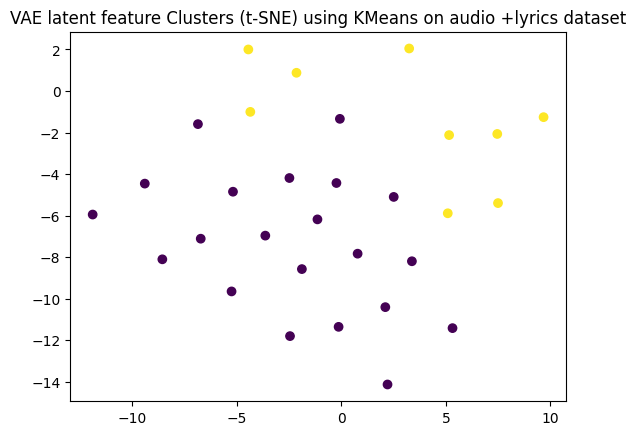

In [94]:
#visualize cluster
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, perplexity=15, random_state=42)
X_2d = tsne.fit_transform(hybrid_features_scaled)

plt.scatter(X_2d[:,0], X_2d[:,1], c=labels_kmeans)
plt.title("VAE latent feature Clusters (t-SNE) using KMeans on audio +lyrics dataset")
plt.show()

In [95]:
from sklearn.cluster import AgglomerativeClustering

agg = AgglomerativeClustering(n_clusters=2)
labels_Agglomerative = agg.fit_predict(hybrid_features_scaled)

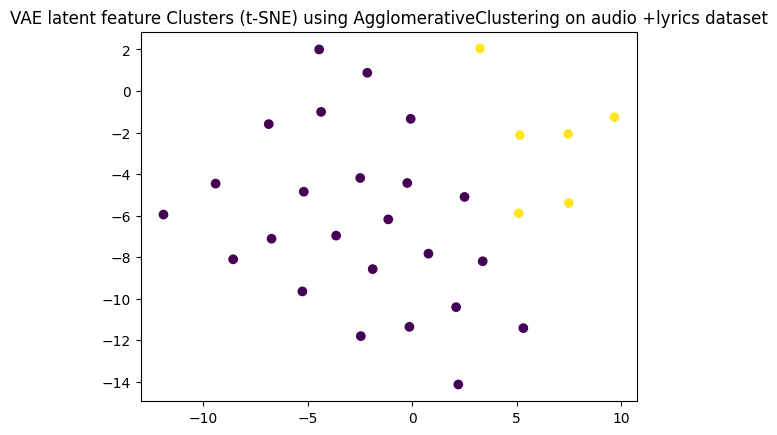

In [97]:
#visualize cluster
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, perplexity=15, random_state=42)
X_2d = tsne.fit_transform(hybrid_features_scaled)

plt.scatter(X_2d[:,0], X_2d[:,1], c=labels_Agglomerative)
plt.title("VAE latent feature Clusters (t-SNE) using AgglomerativeClustering on audio +lyrics dataset")
plt.show()

In [98]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=2.0, min_samples=2)
labels_dbscan = dbscan.fit_predict(hybrid_features_scaled)

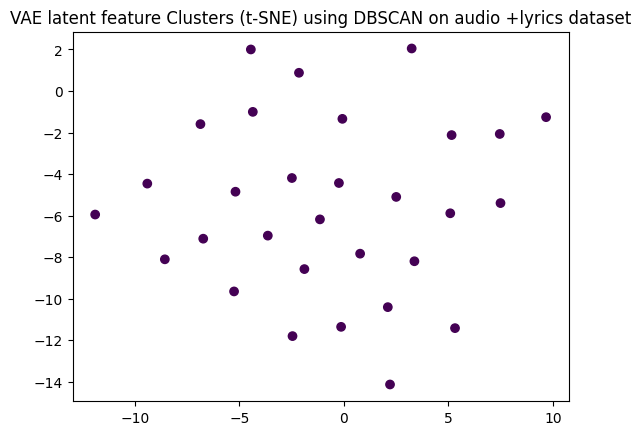

In [99]:
#visualize cluster
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, perplexity=15, random_state=42)
X_2d = tsne.fit_transform(hybrid_features_scaled)

plt.scatter(X_2d[:,0], X_2d[:,1], c=labels_dbscan)
plt.title("VAE latent feature Clusters (t-SNE) using DBSCAN on audio +lyrics dataset")
plt.show()

In [ ]:
###evaluation metrics of clusters

In [100]:
#evaluation metrics
from sklearn.metrics import silhouette_score

score_kmeans = silhouette_score(hybrid_features_scaled, labels_kmeans)
print("KMean Silhouette Score:", score_kmeans)

score_labels_Agglomerative = silhouette_score(hybrid_features_scaled, labels_Agglomerative)
print("Agglomerative Silhouette Score:", score_labels_Agglomerative)

# score_dbscan = silhouette_score(hybrid_features_scaled, labels_dbscan)
# print("DBscan Silhouette Score:", score_dbscan)

KMean Silhouette Score: 0.14505918323993683
Agglomerative Silhouette Score: 0.1888301819562912


In [101]:
from sklearn.metrics import davies_bouldin_score

dbi_kmeans = davies_bouldin_score(hybrid_features, labels_kmeans)
print("dbi_kmeans:", dbi_kmeans)

dbi_Agglomerative = davies_bouldin_score(hybrid_features, labels_Agglomerative)
print("dbi_Agglomerative:", dbi_Agglomerative)

dbi_kmeans: 1.9691629646621762
dbi_Agglomerative: 1.6905541421722445


In [103]:
#baseline(PCA + KMeans)
from sklearn.decomposition import PCA

pca = PCA(n_components=20)  # choose 30–100 usually
X_pca = pca.fit_transform(hybrid_features_scaled)

print(X_pca.shape)

kmeans_pca = KMeans(n_clusters=4)
labels_pca = kmeans_pca.fit_predict(X_pca)

(30, 20)


In [105]:
from sklearn.metrics import silhouette_score


silhouette_score_vae = silhouette_score(hybrid_features_scaled, labels_kmeans)
silhouette_score_pca = silhouette_score(X_pca, labels_pca)
print(silhouette_score_vae,'silhouette_score_vae')
print(silhouette_score_pca ,'silhouette_score_pca ')

0.14505918323993683 silhouette_score_vae
0.03077520802617073 silhouette_score_pca 
